Exploratory Data Analysis: Global Cybersecurity Threats

Import Libraries

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [173]:
# Set global style for light blue bars
custom_color = '#87CEFA'  # Light sky blue

Load dataset

In [176]:
file_path = 'Global_Cybersecurity_Threats_2015-2024.csv'
df = pd.read_csv(file_path)

Display first records

In [179]:
print("First rows:")
display(df.head())

First rows:


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


Show exact column names

Print original column names (raw)

In [183]:
print("\nOriginal Column Names:")
print(df.columns.tolist())


Original Column Names:
['Country', 'Year', 'Attack Type', 'Target Industry', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used', 'Incident Resolution Time (in Hours)']


Clean column names

In [186]:
df.columns = df.columns.str.strip().str.replace('\u200b', '').str.replace('\n', '').str.replace('\r', '').str.title()

 Print cleaned column names

In [189]:
print("\nCleaned Column Names:")
print(df.columns.tolist())


Cleaned Column Names:
['Country', 'Year', 'Attack Type', 'Target Industry', 'Financial Loss (In Million $)', 'Number Of Affected Users', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used', 'Incident Resolution Time (In Hours)']


Basic info

In [192]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              3000 non-null   object 
 1   Year                                 3000 non-null   int64  
 2   Attack Type                          3000 non-null   object 
 3   Target Industry                      3000 non-null   object 
 4   Financial Loss (In Million $)        3000 non-null   float64
 5   Number Of Affected Users             3000 non-null   int64  
 6   Attack Source                        3000 non-null   object 
 7   Security Vulnerability Type          3000 non-null   object 
 8   Defense Mechanism Used               3000 non-null   object 
 9   Incident Resolution Time (In Hours)  3000 non-null   int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 234.5+ KB


Summary statistics

In [195]:
print("\nSummary Statistics:")
display(df.describe(include='all'))


Summary Statistics:


,Country,Year,Attack Type,Target Industry,Financial Loss (In Million $),Number Of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (In Hours)
count,3000,3000.000000,3000,3000,3000.000000,3000.000000,3000,3000,3000,3000.000000
unique,10,NaN,6,7,NaN,NaN,4,4,5,NaN
top,UK,NaN,DDoS,IT,NaN,NaN,Nation-state,Zero-day,Antivirus,NaN
freq,321,NaN,531,478,NaN,NaN,794,785,628,NaN
mean,NaN,2019.570333,NaN,NaN,50.492970,504684.136333,NaN,NaN,NaN,36.476000
std,NaN,2.857932,NaN,NaN,28.791415,289944.084972,NaN,NaN,NaN,20.570768
min,NaN,2015.000000,NaN,NaN,0.500000,424.000000,NaN,NaN,NaN,1.000000
25%,NaN,2017.000000,NaN,NaN,25.757500,255805.250000,NaN,NaN,NaN,19.000000
50%,NaN,2020.000000,NaN,NaN,50.795000,504513.000000,NaN,NaN,NaN,37.000000
75%,NaN,2022.000000,NaN,NaN,75.630000,758088.500000,NaN,NaN,NaN,55.000000


Check for missing values

In [198]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (In Million $)          0
Number Of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (In Hours)    0
dtype: int64


Unique values per column

In [201]:
print("\nUnique Values:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


Unique Values:
Country: 10
Year: 10
Attack Type: 6
Target Industry: 7
Financial Loss (In Million $): 2536
Number Of Affected Users: 2998
Attack Source: 4
Security Vulnerability Type: 4
Defense Mechanism Used: 5
Incident Resolution Time (In Hours): 72


Detect column related to 'threat'

 Set the correct column name manually

In [205]:
threat_col = 'Attack Type'

Frequency of threat types

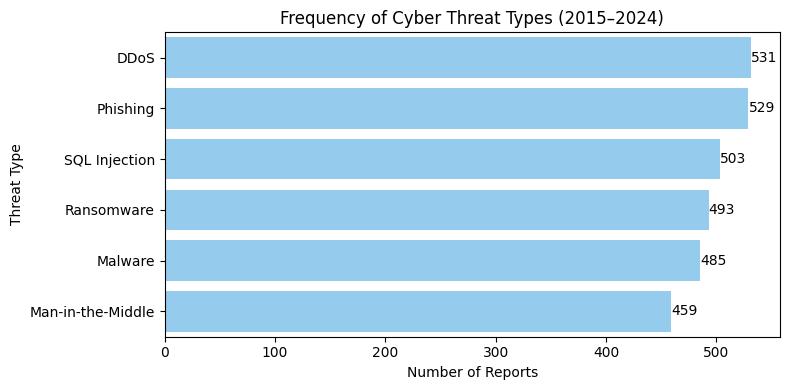

In [208]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(y=threat_col, data=df, order=df[threat_col].value_counts().index, color=custom_color)
plt.title('Frequency of Cyber Threat Types (2015–2024)')
plt.xlabel('Number of Reports')
plt.ylabel('Threat Type')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

Threats over time

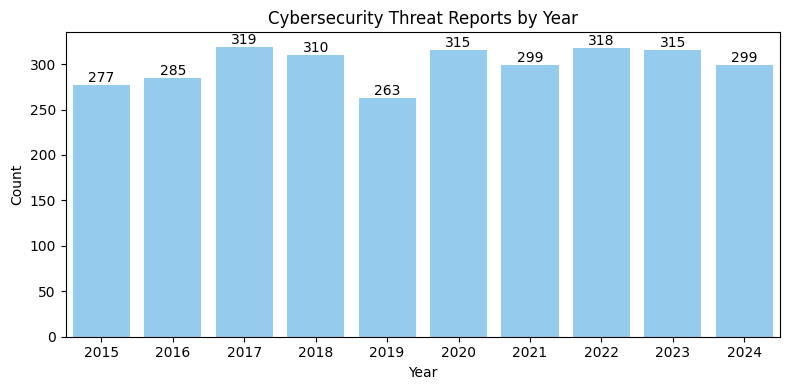

In [219]:
if 'Year' in df.columns:
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(x='Year', data=df, order=sorted(df['Year'].unique()), color=custom_color)
    plt.title('Cybersecurity Threat Reports by Year')
    plt.xlabel('Year')
    plt.ylabel('Count')
    for container in ax.containers:
        ax.bar_label(container)
    plt.tight_layout()
    plt.show()
else:
    print("\n Column 'Year' not found.")

Threats by Country

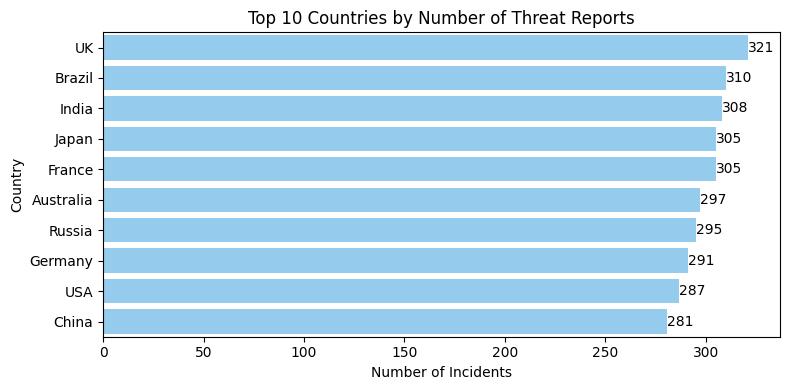

In [223]:
country_cols = [col for col in df.columns if 'country' in col.lower() or 'region' in col.lower()]
if country_cols:
    country_col = country_cols[0]
    top_countries = df[country_col].value_counts().nlargest(10)
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=top_countries.values, y=top_countries.index, color=custom_color)
    plt.title('Top 10 Countries by Number of Threat Reports')
    plt.xlabel('Number of Incidents')
    plt.ylabel('Country')
    for container in ax.containers:
        ax.bar_label(container)
    plt.tight_layout()
    plt.show()
else:
    print("\n Column related to 'Country or Region' not found.")

Security Vulnerability Type distribution if available

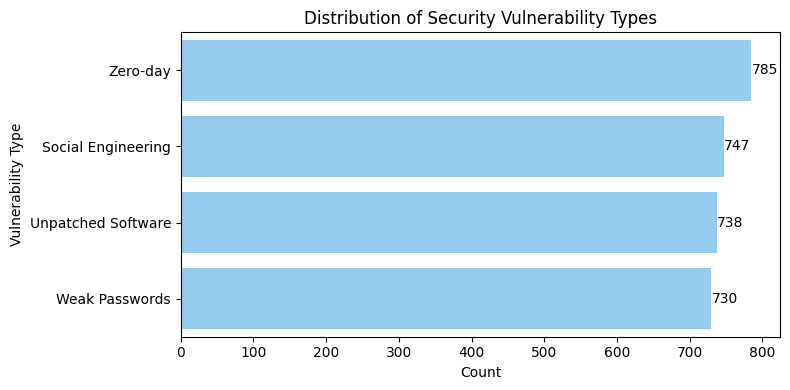

In [226]:
vuln_cols = [col for col in df.columns if 'vulnerability' in col.lower()]
if vuln_cols:
    vuln_col = vuln_cols[0]
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(y=vuln_col, data=df, order=df[vuln_col].value_counts().index, color=custom_color)
    plt.title('Distribution of Security Vulnerability Types')
    plt.xlabel('Count')
    plt.ylabel('Vulnerability Type')
    for container in ax.containers:
        ax.bar_label(container)
    plt.tight_layout()
    plt.show()
else:
    print("\n Column related to 'Security Vulnerability Type' not found.")

Affected industries if available

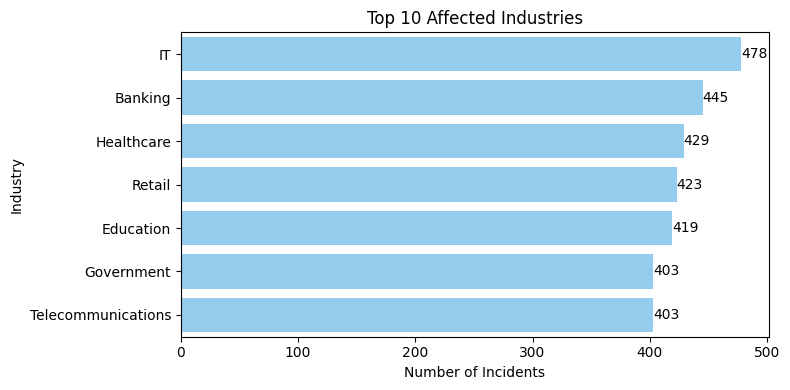

In [229]:
industry_cols = [col for col in df.columns if 'industry' in col.lower()]
if industry_cols:
    industry_col = industry_cols[0]
    top_industries = df[industry_col].value_counts().nlargest(10)
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=top_industries.values, y=top_industries.index, color=custom_color)
    plt.title('Top 10 Affected Industries')
    plt.xlabel('Number of Incidents')
    plt.ylabel('Industry')
    for container in ax.containers:
        ax.bar_label(container)
    plt.tight_layout()
    plt.show()

Defense Mechanism Used distribution if available

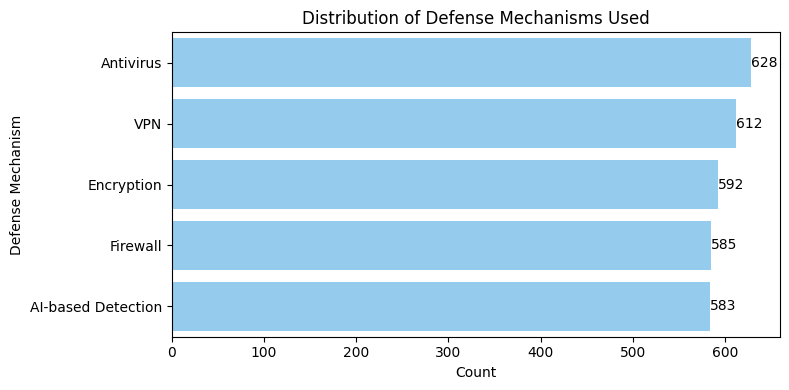

In [231]:
defense_cols = [col for col in df.columns if 'defense mechanism' in col.lower()]
if defense_cols:
    defense_col = defense_cols[0]
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(y=defense_col, data=df, order=df[defense_col].value_counts().index, color=custom_color)
    plt.title('Distribution of Defense Mechanisms Used')
    plt.xlabel('Count')
    plt.ylabel('Defense Mechanism')
    for container in ax.containers:
        ax.bar_label(container)
    plt.tight_layout()
    plt.show()
else:
    print("\n Column related to 'Defense Mechanism Used' not found.")

Resolution Time vs Attack Type 

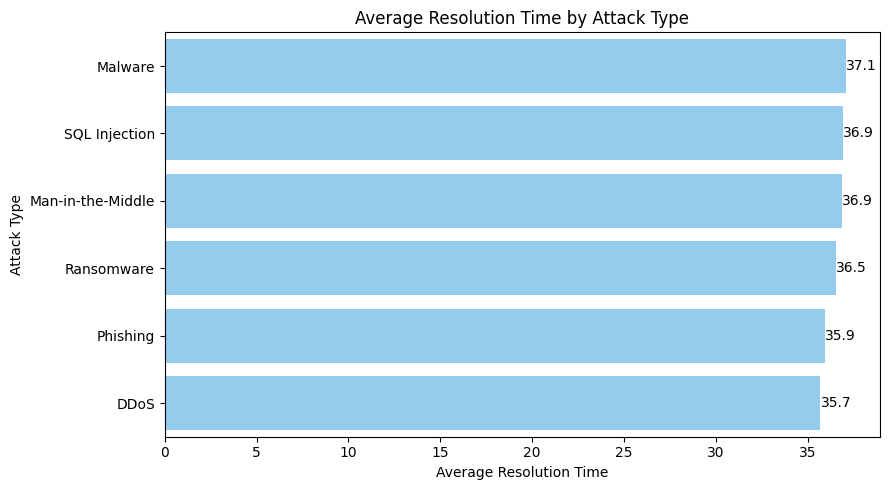

In [233]:
time_cols = [col for col in df.columns if 'resolution' in col.lower() and 'time' in col.lower()]
affected_cols = [col for col in df.columns if 'user' in col.lower() and 'affected' in col.lower()]
if time_cols and affected_cols:
    time_col = time_cols[0]
    affected_col = affected_cols[0]
    if pd.api.types.is_numeric_dtype(df[time_col]) and pd.api.types.is_numeric_dtype(df[affected_col]):
        grouped = df.groupby('Attack Type')[[time_col, affected_col]].mean().sort_values(by=time_col, ascending=False).dropna()
        plt.figure(figsize=(9, 5))
        ax = sns.barplot(data=grouped.reset_index(), x=time_col, y='Attack Type', color=custom_color)
        plt.title('Average Resolution Time by Attack Type')
        plt.xlabel('Average Resolution Time')
        plt.ylabel('Attack Type')
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f')
        plt.tight_layout()
        plt.show()
    else:
        print("\n Columns found but they are not numeric.")
else:
    print("\n Columns related to 'Resolution Time' or 'Users Affected' not found.")